In [13]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('twitter_dataset.csv')

In [3]:
df.head()

,Tweet_ID,Username,Text,Retweets,Likes,Timestamp
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29
4,5,carlwarren,Involve sense former often approach government...,27,80,2023-01-24 07:12:21


In [4]:
countries=['India','USA','UK','Australia','Sri Lanka']
weights=[0.3,0.2,0.2,0.1,0.2]
df['location']=np.random.choice(countries,size=len(df),p=weights)

In [5]:
df.head()

,Tweet_ID,Username,Text,Retweets,Likes,Timestamp,location
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51,India
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58,India
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19,UK
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29,Sri Lanka
4,5,carlwarren,Involve sense former often approach government...,27,80,2023-01-24 07:12:21,India


In [6]:
df['location']=df['location'].astype(str).str.strip().str.lower()

In [7]:
#remove null or empty values
df=df[df['location']!='nan']
df=df[df['location']!='']

In [9]:
location_counts=df['location'].value_counts()

In [11]:
location_counts

location
india        2993
uk           2015
usa          2010
sri lanka    1955
australia    1027
Name: count, dtype: int64

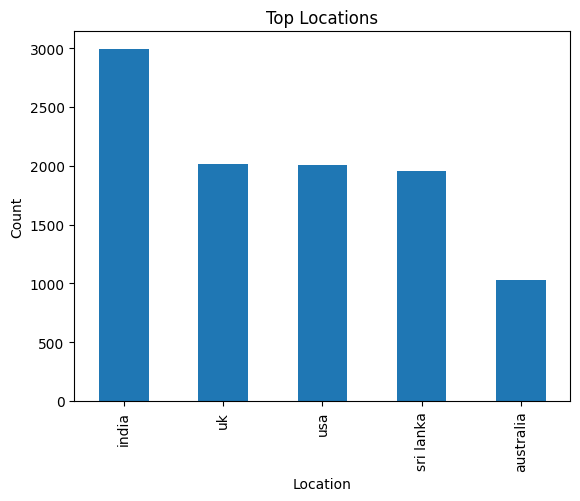

In [15]:
plt.figure()
location_counts.head(10).plot(kind='bar')
plt.title("Top Locations")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

<Axes: ylabel='count'>

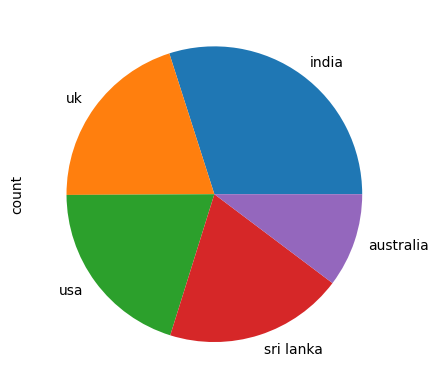

In [16]:
plt.figure()
location_counts.head(5).plot(kind='pie')

<Axes: ylabel='location'>

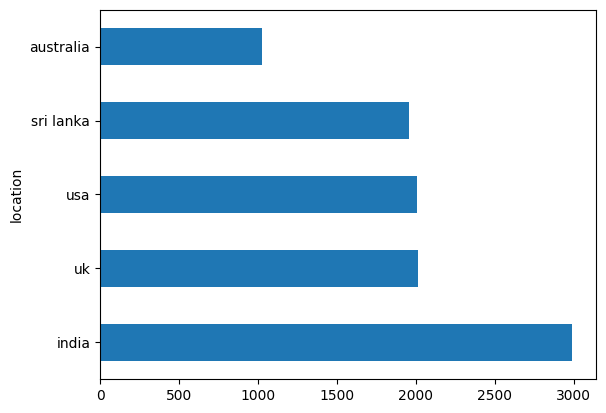

In [17]:
plt.figure()
location_counts.head(10).plot(kind='barh')

<Axes: xlabel='count', ylabel='location'>

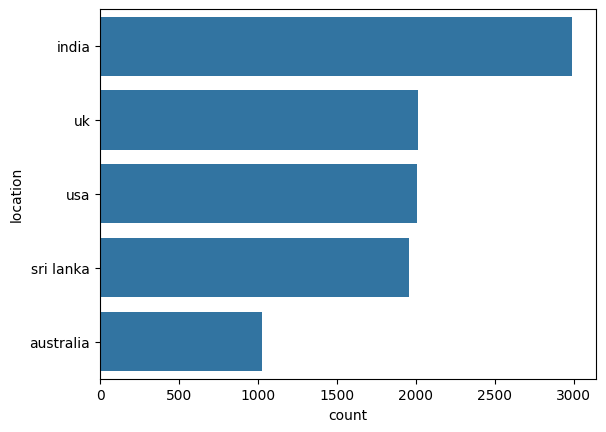

In [19]:
plt.figure()
sns.countplot(y=df['location'],order=location_counts.index)

In [21]:
df['engagement']=df['Likes']+df['Retweets']

In [23]:
engagement_loc=df.groupby('location')['engagement'].sum().sort_values(ascending=False)
print(engagement_loc)

location
india        300357
usa          200968
uk           198387
sri lanka    195251
australia    101542
Name: engagement, dtype: int64


<Axes: xlabel='location'>

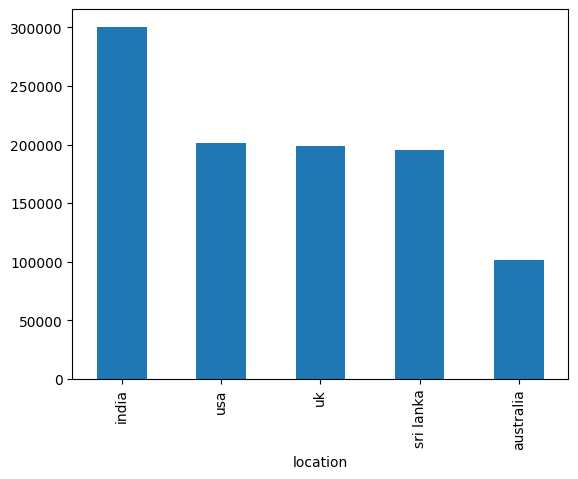

In [24]:
engagement_loc.plot(kind='bar')

In [25]:
avg_likes=df.groupby('location')['Likes'].mean().sort_values(ascending=False)

<Axes: ylabel='location'>

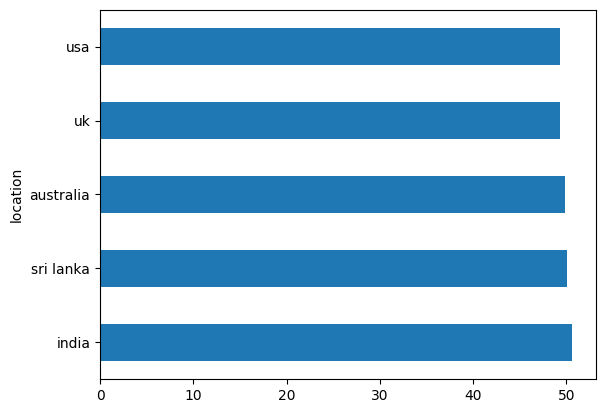

In [26]:
plt.figure()
avg_likes.plot(kind='barh')

<Axes: xlabel='Timestamp'>

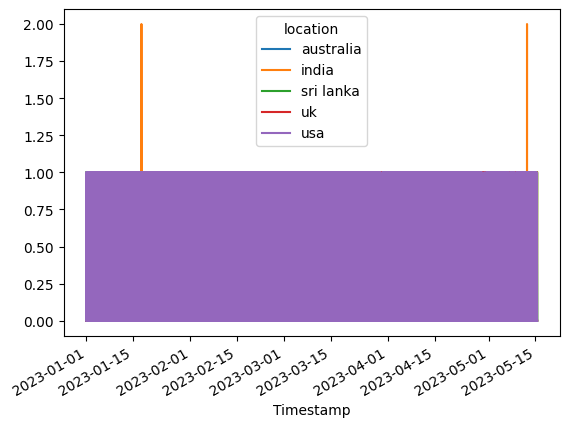

In [28]:
df['Timestamp']=pd.to_datetime(df['Timestamp'])
trend=df.groupby(['Timestamp','location']).size().unstack().fillna(0)
trend.plot()

In [29]:
top_tweets = df.sort_values(by='Likes', ascending=False).groupby('location').head(1)

print(top_tweets[['location','Text','Likes']])

       location                                               Text  Likes
1288         uk  Fight beyond easy nice. Girl happy Democrat fi...    100
4283  australia  Push but smile else protect note nor.\nBase se...    100
8215  sri lanka  Source audience process anyone. Grow loss chai...    100
1292      india  Thousand marriage human majority such focus sc...    100
351         usa  Simply else soon place job must. Before carry ...    100
